## 1. Imports and Device

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
import numpy as np


## 2. Device Configuration and Seed Initialization

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
import random

seed = 42

torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)


## 3. Load CIFAR-10 Dataset

In [3]:
#Basic Transforms
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        (0.5, 0.5, 0.5),
        (0.5, 0.5, 0.5)
    )
])

#Download Dataset
train_dataset = datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.CIFAR10(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

#Create DataLoaders
batch_size = 128

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)


## 5. MLP Starter Code

In [4]:
import torch
import torch.nn as nn

class InitialMLP(nn.Module):
    def __init__(self):
        super().__init__()

        # Hidden Layer 1
        self.fc1 = nn.Linear(32 * 32 * 3, 512)
        
        # Hidden Layer 2
        self.fc2 = nn.Linear(512, 333)
        
        # Hidden Layer 3
        self.fc3 = nn.Linear(333, 20)
        
        # Output Layer (10 classes)
        self.fc4 = nn.Linear(20, 10)

    def forward(self, x):
        x = x.view(x.size(0), -1)  # flatten the 32x32x3 image

        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = torch.relu(self.fc3(x))
        x = self.fc4(x)            # No activation on the final output layer

        return x

## 6. Initialize Network

In [5]:
model = InitialMLP().to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)


## 7. Training Function

In [6]:
def train(model, loader):

    model.train()

    running_loss = 0
    correct = 0
    total = 0

    gradient_norms = {}

    for images, labels in loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        # Save gradient norms
        for name, param in model.named_parameters():

            if param.grad is not None:

                grad_norm = param.grad.norm().item()

                if name not in gradient_norms:
                    gradient_norms[name] = []

                gradient_norms[name].append(grad_norm)

        optimizer.step()

        running_loss += loss.item()

        _, predicted = outputs.max(1)

        total += labels.size(0)

        correct += predicted.eq(labels).sum().item()

    accuracy = 100 * correct / total

    avg_loss = running_loss / len(loader)

    return avg_loss, accuracy, gradient_norms


## 8. Testing Function

In [7]:
def test(model, loader):

    model.eval()

    running_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_loss += loss.item()

            _, predicted = outputs.max(1)

            total += labels.size(0)

            correct += predicted.eq(labels).sum().item()

    accuracy = 100 * correct / total

    avg_loss = running_loss / len(loader)

    return avg_loss, accuracy


## 9. Main Training Loop

In [ ]:
import os
import numpy as np
import torch
import torch.nn.functional as F
from tqdm.notebook import tqdm

num_epochs = 15

train_losses, test_losses, train_accs, test_accs = [], [], [], []
epoch_gradient_norms = {}

print("Starting Training Process...\n")


pbar = tqdm(range(num_epochs), desc="Training Model", unit="epoch")

for epoch in pbar:
    
    train_loss, train_acc, batch_grad_norms = train(model, train_loader)
    test_loss, test_acc = test(model, test_loader)

    train_losses.append(train_loss)
    test_losses.append(test_loss)
    train_accs.append(train_acc)
    test_accs.append(test_acc)

    for name, norms in batch_grad_norms.items():
        if name not in epoch_gradient_norms:
            epoch_gradient_norms[name] = []
        epoch_gradient_norms[name].append(np.mean(norms))

    pbar.set_postfix({
        'Train Acc': f"{train_acc:.2f}%", 
        'Test Acc': f"{test_acc:.2f}%"
    })

print("-" * 40)
print("Training Complete. Starting Deep Evaluation on Test Set...\n")


model.eval()
all_labels, all_preds, all_probs, all_logits = [], [], [], []
wrong_images, wrong_true, wrong_pred = [], [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        
        probs = F.softmax(outputs, dim=1)
        _, preds = torch.max(outputs, 1)
        
        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
        all_logits.extend(outputs.cpu().numpy())
        
        
        wrong_idx = (preds != labels).nonzero(as_tuple=True)[0]
        for idx in wrong_idx:
            if len(wrong_images) < 100:
                wrong_images.append(images[idx].cpu().numpy())
                wrong_true.append(labels[idx].item())
                wrong_pred.append(preds[idx].item())


output_dir = r"C:\neural networks\part 2" 
if not os.path.exists(output_dir):
    os.makedirs(output_dir)


npz_path = os.path.join(output_dir, "MLP.npz")
pth_path = os.path.join(output_dir, "MLP_weights.pth")


torch.save(model.state_dict(), pth_path)


save_dict = {
    'train_losses': np.array(train_losses),
    'test_losses': np.array(test_losses),
    'train_accs': np.array(train_accs),
    'test_accs': np.array(test_accs),
    'all_labels': np.array(all_labels),
    'all_preds': np.array(all_preds),
    'all_probs': np.array(all_probs),
    'all_logits': np.array(all_logits),
    'wrong_images': np.array(wrong_images),
    'wrong_true': np.array(wrong_true),
    'wrong_pred': np.array(wrong_pred)
}


for k, v in epoch_gradient_norms.items():
    save_dict[f'grad_{k}'] = np.array(v)

np.savez_compressed(npz_path, **save_dict)

print(f"Success! Model weights saved to: {pth_path}")
print(f"Success! All analytics data packed and saved to: {npz_path}")

Starting Training Process...



Training Model:   0%|          | 0/15 [00:00<?, ?epoch/s]

----------------------------------------
Training Complete. Starting Deep Evaluation on Test Set...

Success! Model weights saved to: C:\neural networks\part 2\MLP_weights.pth
Success! All analytics data packed and saved to: C:\neural networks\part 2\MLP.npz


# Part 2 answers

## number of parameters

In [11]:
import torch
import torch.nn as nn

# 1. Your exact MLP definition
class CustomMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(32 * 32 * 3, 512)
        self.fc2 = nn.Linear(512, 333)
        self.fc3 = nn.Linear(333, 20)
        self.fc4 = nn.Linear(20, 10)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = torch.relu(self.fc3(x))
        x = self.fc4(x)
        return x

# 2. The parameter counting function
def print_model_parameters(model):
    total_params = 0
    
    # Print the table header
    print(f"{'Layer / Parameter':<20} | {'Grid Shape':<15} | {'Parameter Count':<15}")
    print("-" * 55)
    
    # Loop through every weight and bias in the model
    for name, param in model.named_parameters():
        if param.requires_grad:
            # .numel() counts the total number of elements in the tensor
            num_params = param.numel()
            total_params += num_params
            
            # Format the output so it's easy to read
            shape_str = str(list(param.size()))
            print(f"{name:<20} | {shape_str:<15} | {num_params:,}")
            
    print("-" * 55)
    print(f"TOTAL PARAMETERS: {total_params:,}\n")

# 3. Initialize the model and run the counter
model = CustomMLP()
print_model_parameters(model)

Layer / Parameter    | Grid Shape      | Parameter Count
-------------------------------------------------------
fc1.weight           | [512, 3072]     | 1,572,864
fc1.bias             | [512]           | 512
fc2.weight           | [333, 512]      | 170,496
fc2.bias             | [333]           | 333
fc3.weight           | [20, 333]       | 6,660
fc3.bias             | [20]            | 20
fc4.weight           | [10, 20]        | 200
fc4.bias             | [10]            | 10
-------------------------------------------------------
TOTAL PARAMETERS: 1,751,095



## plot weights

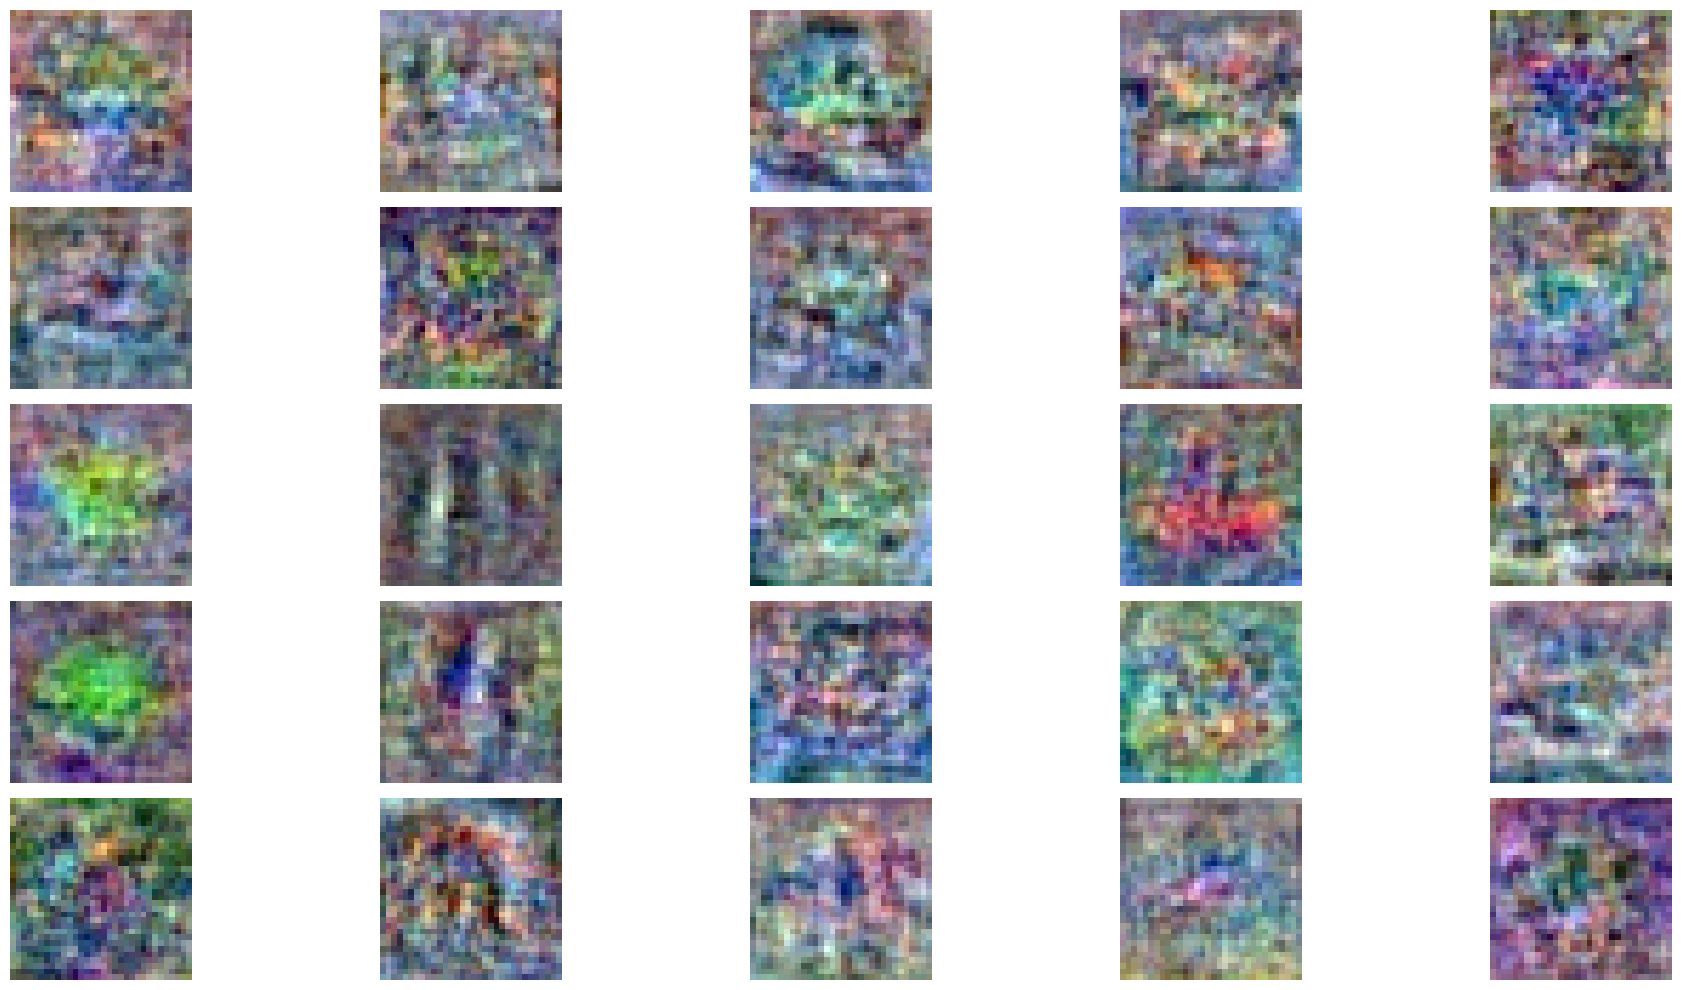

In [4]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch


def plot_weights(weights, n_weights):
    n_weights = min(n_weights, weights.shape[0])
    grid_size = int(np.ceil(np.sqrt(n_weights)))

    fig = plt.figure(figsize=(20, 10))
    for i in range(n_weights):
        ax = fig.add_subplot(grid_size, grid_size, i + 1)
        weight = weights[i].detach().cpu().view(3, 32, 32).permute(1, 2, 0).numpy()
        weight = weight - weight.min()
        max_value = weight.max()
        if max_value > 0:
            weight = weight / max_value
        ax.imshow(weight)
        ax.axis('off')

    plt.tight_layout()
    plt.show()


weight_path = Path(r"C:\neural networks\part 2\MLP_weights.pth")
checkpoint = torch.load(weight_path, map_location='cpu')

if isinstance(checkpoint, dict):
    if 'fc1.weight' in checkpoint:
        weights = checkpoint['fc1.weight']
    elif 'model_state_dict' in checkpoint and 'fc1.weight' in checkpoint['model_state_dict']:
        weights = checkpoint['model_state_dict']['fc1.weight']
    elif 'state_dict' in checkpoint and 'fc1.weight' in checkpoint['state_dict']:
        weights = checkpoint['state_dict']['fc1.weight']
    else:
        raise KeyError('Could not find fc1.weight in the saved checkpoint.')
else:
    weights = checkpoint.fc1.weight.detach()

plot_weights(weights, 25)

## memory required

In [12]:
import torch

def calculate_model_memory(model):
    # 1. Count all parameters (weights + biases)
    total_params = sum(p.numel() for p in model.parameters())
    
    # 2. Calculate memory in bytes (4 bytes per float32 parameter)
    param_bytes = total_params * 4
    
    # 3. Convert bytes to Megabytes (MB)
    param_mb = param_bytes / (1024 ** 2)
    
    print("-" * 50)
    print("🧠 MODEL MEMORY REPORT")
    print("-" * 50)
    print(f"Total Parameters: {total_params:,}")
    print(f"Base Memory (Weights only): {param_mb:.2f} MB")
    
    # 4. Estimate Training Memory Overhead
    # - Gradients: take the exact same amount of memory as parameters
    # - Optimizer (SGD with Momentum): stores one "velocity" copy for every parameter
    grad_mb = param_mb
    optimizer_mb = param_mb
    
    total_train_mb = param_mb + grad_mb + optimizer_mb
    
    print(f"\nEstimated Training Memory (Params + Grads + Optimizer): {total_train_mb:.2f} MB")
    print("-" * 50)
    print("*Note: This does not include the memory required for holding the Batch of Images and Intermediate Activations.")

# Run the function on your MLP
calculate_model_memory(model)

--------------------------------------------------
🧠 MODEL MEMORY REPORT
--------------------------------------------------
Total Parameters: 1,751,095
Base Memory (Weights only): 6.68 MB

Estimated Training Memory (Params + Grads + Optimizer): 20.04 MB
--------------------------------------------------
*Note: This does not include the memory required for holding the Batch of Images and Intermediate Activations.


# Evaluation methods

## loss, accuracy

Plot saved successfully to: C:\neural networks\part 2\loss_accuracy_plot.png


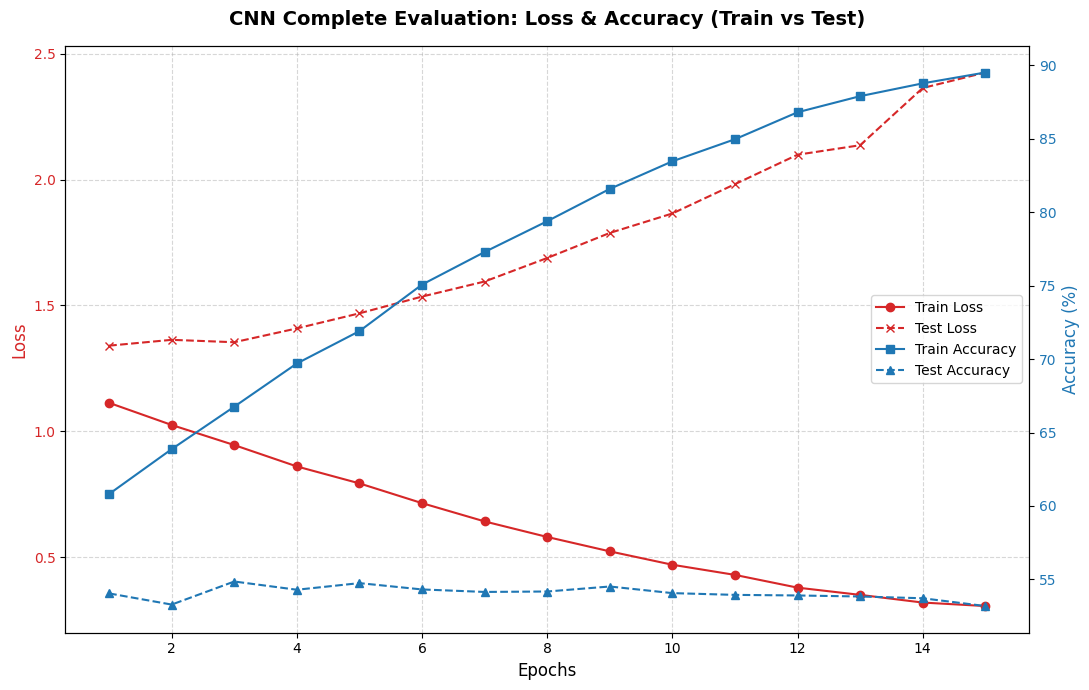

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt


output_dir = r"C:\neural networks\part 2"
npz_path = os.path.join(output_dir, "MLP.npz")

data = np.load(npz_path)
train_losses = data['train_losses']
test_losses = data['test_losses']
train_accs = data['train_accs']
test_accs = data['test_accs']
num_epochs = len(train_losses)


fig, ax1 = plt.subplots(figsize=(11, 7))


color_loss = 'tab:red'
ax1.set_xlabel('Epochs', fontsize=12)
ax1.set_ylabel('Loss', color=color_loss, fontsize=12)


line1 = ax1.plot(range(1, num_epochs + 1), train_losses, color=color_loss, 
                 linestyle='-', marker='o', label='Train Loss')
line2 = ax1.plot(range(1, num_epochs + 1), test_losses, color=color_loss, 
                 linestyle='--', marker='x', label='Test Loss')
ax1.tick_params(axis='y', labelcolor=color_loss)
ax1.grid(True, linestyle='--', alpha=0.5)


ax2 = ax1.twinx()  
color_acc = 'tab:blue'
ax2.set_ylabel('Accuracy (%)', color=color_acc, fontsize=12)


line3 = ax2.plot(range(1, num_epochs + 1), train_accs, color=color_acc, 
                 linestyle='-', marker='s', label='Train Accuracy')
line4 = ax2.plot(range(1, num_epochs + 1), test_accs, color=color_acc, 
                 linestyle='--', marker='^', label='Test Accuracy')
ax2.tick_params(axis='y', labelcolor=color_acc)


lines = line1 + line2 + line3 + line4
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='center right', fontsize=10)


plt.title('CNN Complete Evaluation: Loss & Accuracy (Train vs Test)', fontsize=14, fontweight='bold', pad=15)

plt.tight_layout()


plot_path = os.path.join(output_dir, "loss_accuracy_plot.png")
plt.savefig(plot_path, dpi=300)
print(f"Plot saved successfully to: {plot_path}")


plt.show()

## AUC, f1 score

=== F1 Score: 0.5327 ===
הסבר: מדד המאזן בין פספוסים (False Negatives) לאזעקות שווא (False Positives).

Plot saved successfully to: C:\neural networks\part 2\roc_auc_plot.png



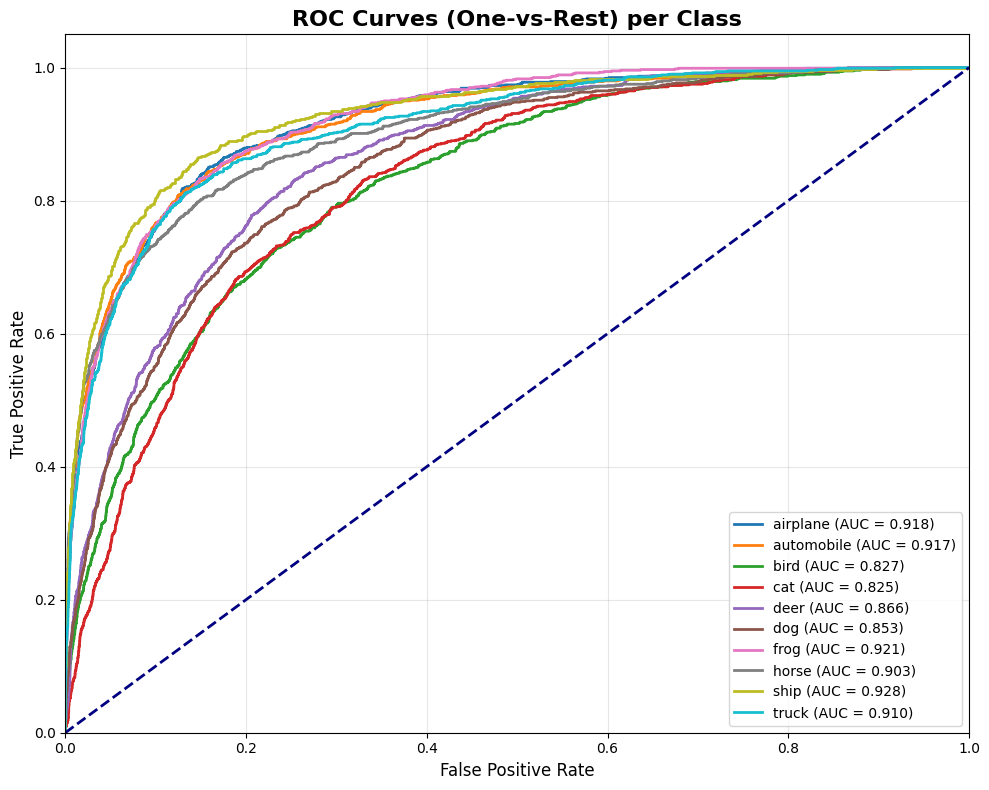

הסבר AUC: הציון נע בין 0.5 (ניחוש לחלוטין) ל-1.0 (הפרדה מושלמת).
מחלקות עם AUC נמוך הן אלו שהמודל הכי מתבלבל בהן לעומת שאר הקטגוריות.


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, roc_curve, auc
from sklearn.preprocessing import label_binarize


output_dir = r"C:\neural networks\part 2"
npz_path = os.path.join(output_dir, "MLP.npz")

data = np.load(npz_path)
all_labels = data['all_labels']
all_preds = data['all_preds']
all_probs = data['all_probs']


cifar_classes = ['airplane', 'automobile', 'bird', 'cat', 'deer', 
                 'dog', 'frog', 'horse', 'ship', 'truck']


f1 = f1_score(all_labels, all_preds, average='macro')
print(f"=== F1 Score: {f1:.4f} ===")
print("הסבר: מדד המאזן בין פספוסים (False Negatives) לאזעקות שווא (False Positives).\n")


y_test_bin = label_binarize(all_labels, classes=range(10))

plt.figure(figsize=(10, 8))
for i in range(10):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], all_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'{cifar_classes[i]} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves (One-vs-Rest) per Class', fontsize=16, fontweight='bold')
plt.legend(loc="lower right", fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()


plot_path = os.path.join(output_dir, "roc_auc_plot.png")
plt.savefig(plot_path, dpi=300)
print(f"Plot saved successfully to: {plot_path}\n")


plt.show()

print("הסבר AUC: הציון נע בין 0.5 (ניחוש לחלוטין) ל-1.0 (הפרדה מושלמת).")
print("מחלקות עם AUC נמוך הן אלו שהמודל הכי מתבלבל בהן לעומת שאר הקטגוריות.")

## confusion matrix

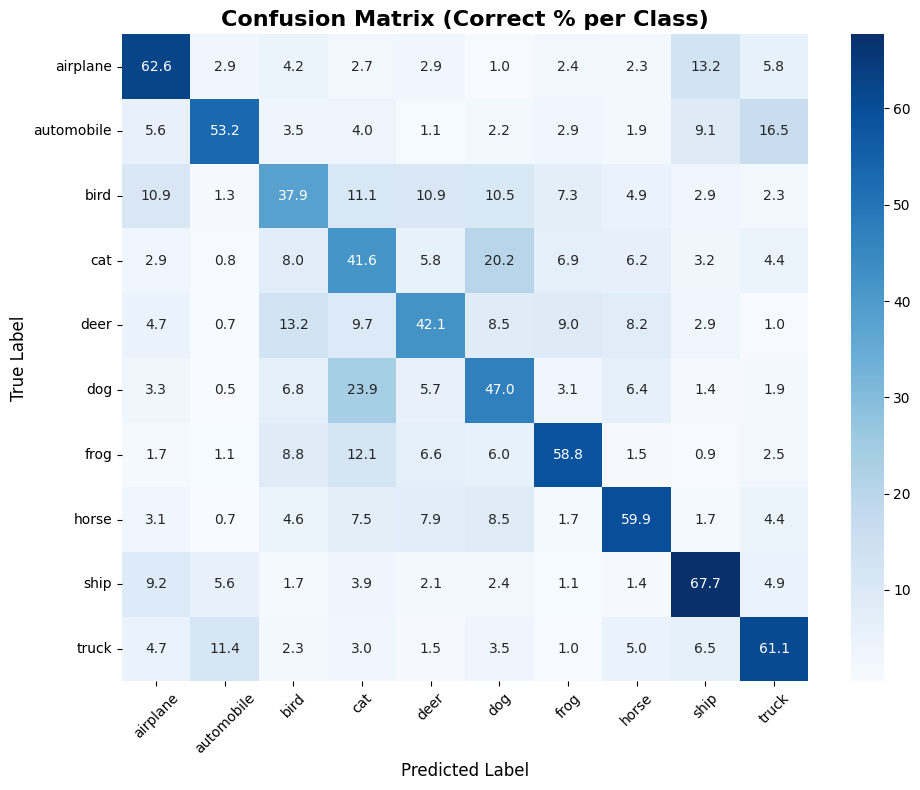

In [15]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(all_labels, all_preds)
cm_percentages = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

plt.figure(figsize=(10, 8))
sns.heatmap(cm_percentages, annot=True, fmt='.1f', cmap='Blues', 
            xticklabels=cifar_classes, yticklabels=cifar_classes)
plt.title('Confusion Matrix (Correct % per Class)', fontsize=16, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## MisClassification

Plot saved successfully to: C:\neural networks\part 2\misclassified_examples.png



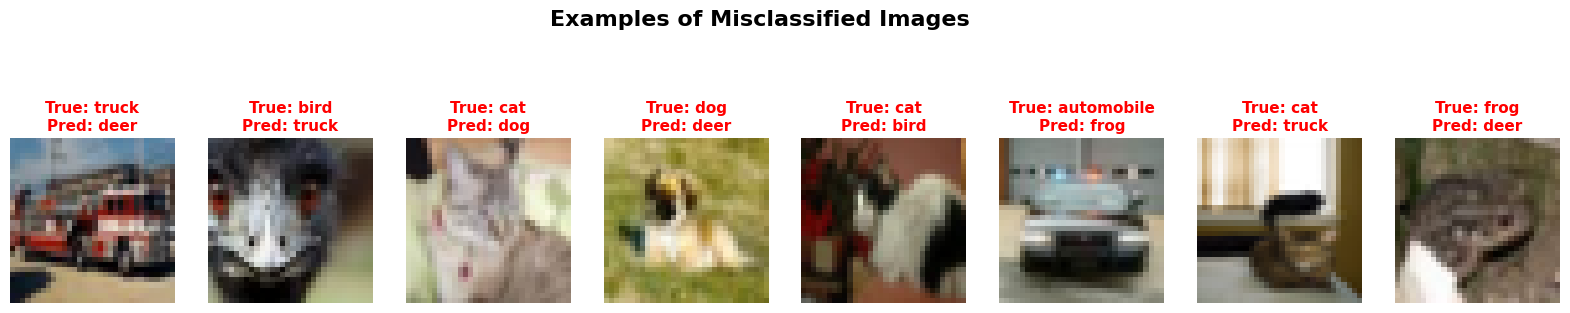

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import random


output_dir = r"C:\neural networks\part 2"
npz_path = os.path.join(output_dir, "MLP.npz")

data = np.load(npz_path)
wrong_images = data['wrong_images']
wrong_true = data['wrong_true']
wrong_pred = data['wrong_pred']

cifar_classes = ['airplane', 'automobile', 'bird', 'cat', 'deer', 
                 'dog', 'frog', 'horse', 'ship', 'truck']


def imshow_unnorm(img_array):
    img = img_array / 2 + 0.5     
    img = np.clip(img, 0, 1)      
    return np.transpose(img, (1, 2, 0)) 


num_errors = len(wrong_images)
sample_size = min(8, num_errors)
sample_indices = random.sample(range(num_errors), sample_size)


fig, axes = plt.subplots(1, sample_size, figsize=(20, 3))
if sample_size == 1: axes = [axes] 

fig.suptitle('Examples of Misclassified Images', fontsize=16, fontweight='bold', y=1.2)

for ax, idx in zip(axes, sample_indices):
    img_array = wrong_images[idx]
    true_label = cifar_classes[wrong_true[idx]]
    pred_label = cifar_classes[wrong_pred[idx]]
    
    ax.imshow(imshow_unnorm(img_array))
    ax.set_title(f"True: {true_label}\nPred: {pred_label}", 
                 color='red', fontsize=11, fontweight='bold')
    ax.axis('off')


plot_path = os.path.join(output_dir, "misclassified_examples.png")
plt.savefig(plot_path, dpi=300, bbox_inches='tight')
print(f"Plot saved successfully to: {plot_path}\n")

plt.show()